# Verify fixed & merged H5 file

Plot static images, postage stamps, and point source locations from the merged_cleaned H5 file,
to verify that `fix_h5_metadata.py` + `merge_h5.py` + `merge_clean_h5.py` produced correct results.

In [104]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [105]:
%matplotlib inline

In [106]:
MAG_ZPS_CPS = {
    'u': 26.52,
    'g': 28.51,
    'r': 28.36,
    'i': 28.17,
    'z': 27.78,
    'y': 26.82,
}

PIX2ARCSEC = 0.2

def flux2mag(flux, band, exposure_time=30.):
    return -2.5 * np.log10(flux / exposure_time) + MAG_ZPS_CPS[band]

def mag2flux(mag, band, exposure_time=30.):
    return 10**((mag - MAG_ZPS_CPS[band]) / (-2.5)) * exposure_time

In [107]:
#filename = "3000sqdeg_lsst_1y_sample_merged_cleaned.h5"
folder = "/home/users/shenming/claude_code_test/source_injection_detection/SL_AGN/lens_finding_postage_stamps_dataset"
filename = f"{folder}/3000sqdeg_lsst_1y_sample_7.h5"
hf = h5py.File(filename, "r")
print("Number of systems:", len(hf))

Number of systems: 454


## Helper functions

In [108]:
def get_point_xy(ind, band, hf=hf):
    """Get point source pixel coords relative to stamp center."""
    ind_tmp = ind
#    ind_tmp = None
#    if ind<24:
#        ind_tmp = ind
#    if ind>24:
#        ind_tmp = ind + 1
    metadata = hf[f'lsst_lens_{ind_tmp}']['metadata']
    n_images = len(hf[f'lsst_lens_{ind}']['light_curves'])
    x_c, y_c = 16, 16  # stamp center
    xs, ys = [], []
    for ind2 in range(n_images):
        dx = metadata.attrs[f'point_source_light_{band}_ra_image_{ind2}'] / PIX2ARCSEC
        dy = metadata.attrs[f'point_source_light_{band}_dec_image_{ind2}'] / PIX2ARCSEC
        xs.append(x_c + dx)
        ys.append(y_c + dy)
    return xs, ys


def _plot_points(ax, xs, ys):
    """Plot point source dots with image_N labels."""
    ax.plot(xs, ys, 'm.', ms=8)
    for ind2, (x, y) in enumerate(zip(xs, ys)):
        ax.text(x + 0.5, y + 0.5, f'img_{ind2}', color='m', fontsize=7)


def plot_static(ind, band, hf=hf):
    """Plot the static image (host galaxy + lensed arc)."""
    arr = hf[f'lsst_lens_{ind}']['static_image'][band]['lens_plus_lensed_agn_host'][:]
    plt.figure(figsize=(4, 4))
    plt.imshow(np.arcsinh(arr), origin="lower")
    plt.colorbar()
    plt.title(f"Static image: lens {ind}, {band}-band")


def plot_stamp(ind, band, time_index=0, hf=hf):
    """Plot a postage stamp with point source locations overlaid."""
    arr = hf[f'lsst_lens_{ind}']['postage_stamps'][band]['all_observations'][time_index]
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(np.arcsinh(arr), origin="lower")
    xs, ys = get_point_xy(ind, band)
    _plot_points(ax, xs, ys)
    ax.set_title(f"Stamp: lens {ind}, {band}-band, t={time_index}")
    plt.colorbar(ax.images[0])


def plot_diff(ind, band, time_index=0, hf=hf):
    """Plot stamp - stamp_mean (smoothed), overlay point sources, verify flux vs light curve mag."""
    arr_static = hf[f'lsst_lens_{ind}']['static_image'][band]['lens_plus_lensed_agn_host'][:]
    arr_stamp = hf[f'lsst_lens_{ind}']['postage_stamps'][band]['all_observations'][time_index]
    arr_stamp_mean = np.mean(
        hf[f'lsst_lens_{ind}']['postage_stamps'][band]['all_observations'][:], axis=0
    )

    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(
        np.arcsinh(gaussian_filter(arr_stamp - arr_stamp_mean, sigma=2)),
        origin="lower", vmin=-8, vmax=8, cmap='bwr'
    )
    plt.colorbar(im)

    xs, ys = get_point_xy(ind, band)
    _plot_points(ax, xs, ys)
    ax.set_title(f"Diff (stamp - mean): lens {ind}, {band}, t={time_index}")

    # Verify: extract point source flux and compare to light curve mag
    light_curves = hf[f'lsst_lens_{ind}']['light_curves']
    point_src = arr_stamp - arr_static
    for ind2 in range(len(xs)):
        x, y = int(xs[ind2]), int(ys[ind2])
        arr_sel = point_src[y-1:y+3, x-1:x+3]
        print(arr_sel)
        total_flux = np.sum(arr_sel)
        lc_mag = light_curves[f'image_{ind2}'][band][time_index]
        print(f"  image_{ind2}: flux_mag={flux2mag(total_flux, band):.2f}, lc_mag={lc_mag:.2f}")

## Pick a system to inspect

In [109]:
ind = 233
band = 'i'

n_images = len(hf[f'lsst_lens_{ind}']['light_curves'])
n_epochs = hf[f'lsst_lens_{ind}']['postage_stamps'][band]['all_observations'].shape[0]
print(f"Lens {ind}: {n_images} point source images, {n_epochs} epochs")

Lens 233: 2 point source images, 14 epochs


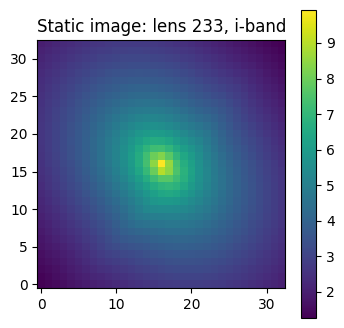

In [110]:
plot_static(ind, band)

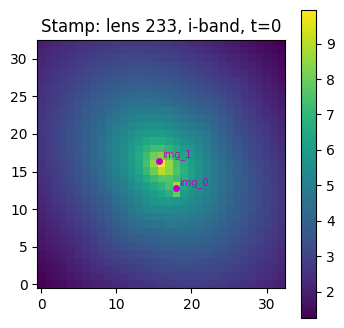

In [111]:
plot_stamp(ind, band, time_index=0)

[[   0.            0.            0.            0.        ]
 [   0.          106.80468984  998.28277834    0.        ]
 [   0.          305.31765955 2853.74511093    0.        ]
 [   0.            0.            0.            0.        ]]
  image_0: flux_mag=22.79, lc_mag=22.79
[[  0.           0.           0.           0.        ]
 [  0.          95.5391066  189.05679084   0.        ]
 [  0.          78.13690712 154.62058869   0.        ]
 [  0.           0.           0.           0.        ]]
  image_1: flux_mag=25.08, lc_mag=25.08


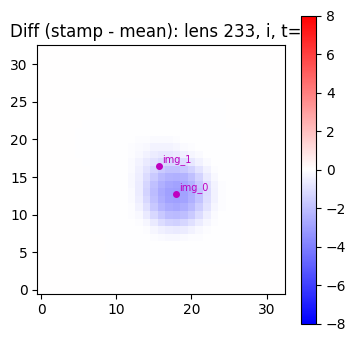

In [112]:
plot_diff(ind, band, time_index=0)

[[   0.            0.            0.            0.        ]
 [   0.          106.0720527   991.43496075    0.        ]
 [   0.          303.22330344 2834.16956942    0.        ]
 [   0.            0.            0.            0.        ]]
  image_0: flux_mag=22.80, lc_mag=22.80
[[  0.           0.           0.           0.        ]
 [  0.          92.76994531 183.57705834   0.        ]
 [  0.          75.87214134 150.13897519   0.        ]
 [  0.           0.           0.           0.        ]]
  image_1: flux_mag=25.11, lc_mag=25.11


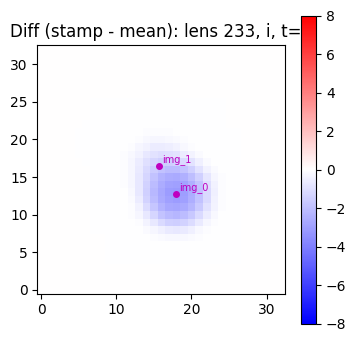

In [113]:
plot_diff(ind, band, time_index=2)

## Spot check multiple systems

Check a few systems across the merged file to verify consistency.

In [114]:
n_total = len(hf)
check_indices = [11, 22, 33, 55, 66, 99, 111, 155, 188, 222, 266, 299, 333, 355, 399, n_total - 1]
check_indices = [i for i in check_indices if i < n_total]

for ind in check_indices:
    n_images = len(hf[f'lsst_lens_{ind}']['light_curves'])
    xs, ys = get_point_xy(ind, 'i')
    print(f"Lens {ind}: {n_images} images, point x={[f'{x:.1f}' for x in xs]}, y={[f'{y:.1f}' for y in ys]}")

Lens 11: 2 images, point x=['18.6', '14.8'], y=['18.6', '15.5']
Lens 22: 2 images, point x=['8.9', '18.1'], y=['10.4', '17.7']
Lens 33: 3 images, point x=['18.1', '15.6', '15.8'], y=['15.9', '16.2', '16.2']
Lens 55: 2 images, point x=['16.7', '14.5'], y=['13.5', '16.7']
Lens 66: 2 images, point x=['14.9', '16.0'], y=['18.4', '14.9']
Lens 99: 2 images, point x=['13.0', '17.8'], y=['19.4', '13.1']
Lens 111: 2 images, point x=['19.5', '15.5'], y=['16.1', '15.8']
Lens 155: 2 images, point x=['5.7', '20.7'], y=['27.8', '12.7']
Lens 188: 2 images, point x=['12.2', '16.6'], y=['10.8', '16.9']
Lens 222: 4 images, point x=['12.1', '17.3', '13.8', '19.4'], y=['20.2', '12.1', '12.6', '17.6']
Lens 266: 2 images, point x=['18.6', '15.0'], y=['13.5', '17.2']
Lens 299: 2 images, point x=['21.4', '15.6'], y=['12.5', '16.2']
Lens 333: 2 images, point x=['12.0', '16.8'], y=['8.8', '17.7']
Lens 355: 2 images, point x=['12.2', '17.1'], y=['12.4', '18.8']
Lens 399: 2 images, point x=['17.2', '15.3'], y=['1

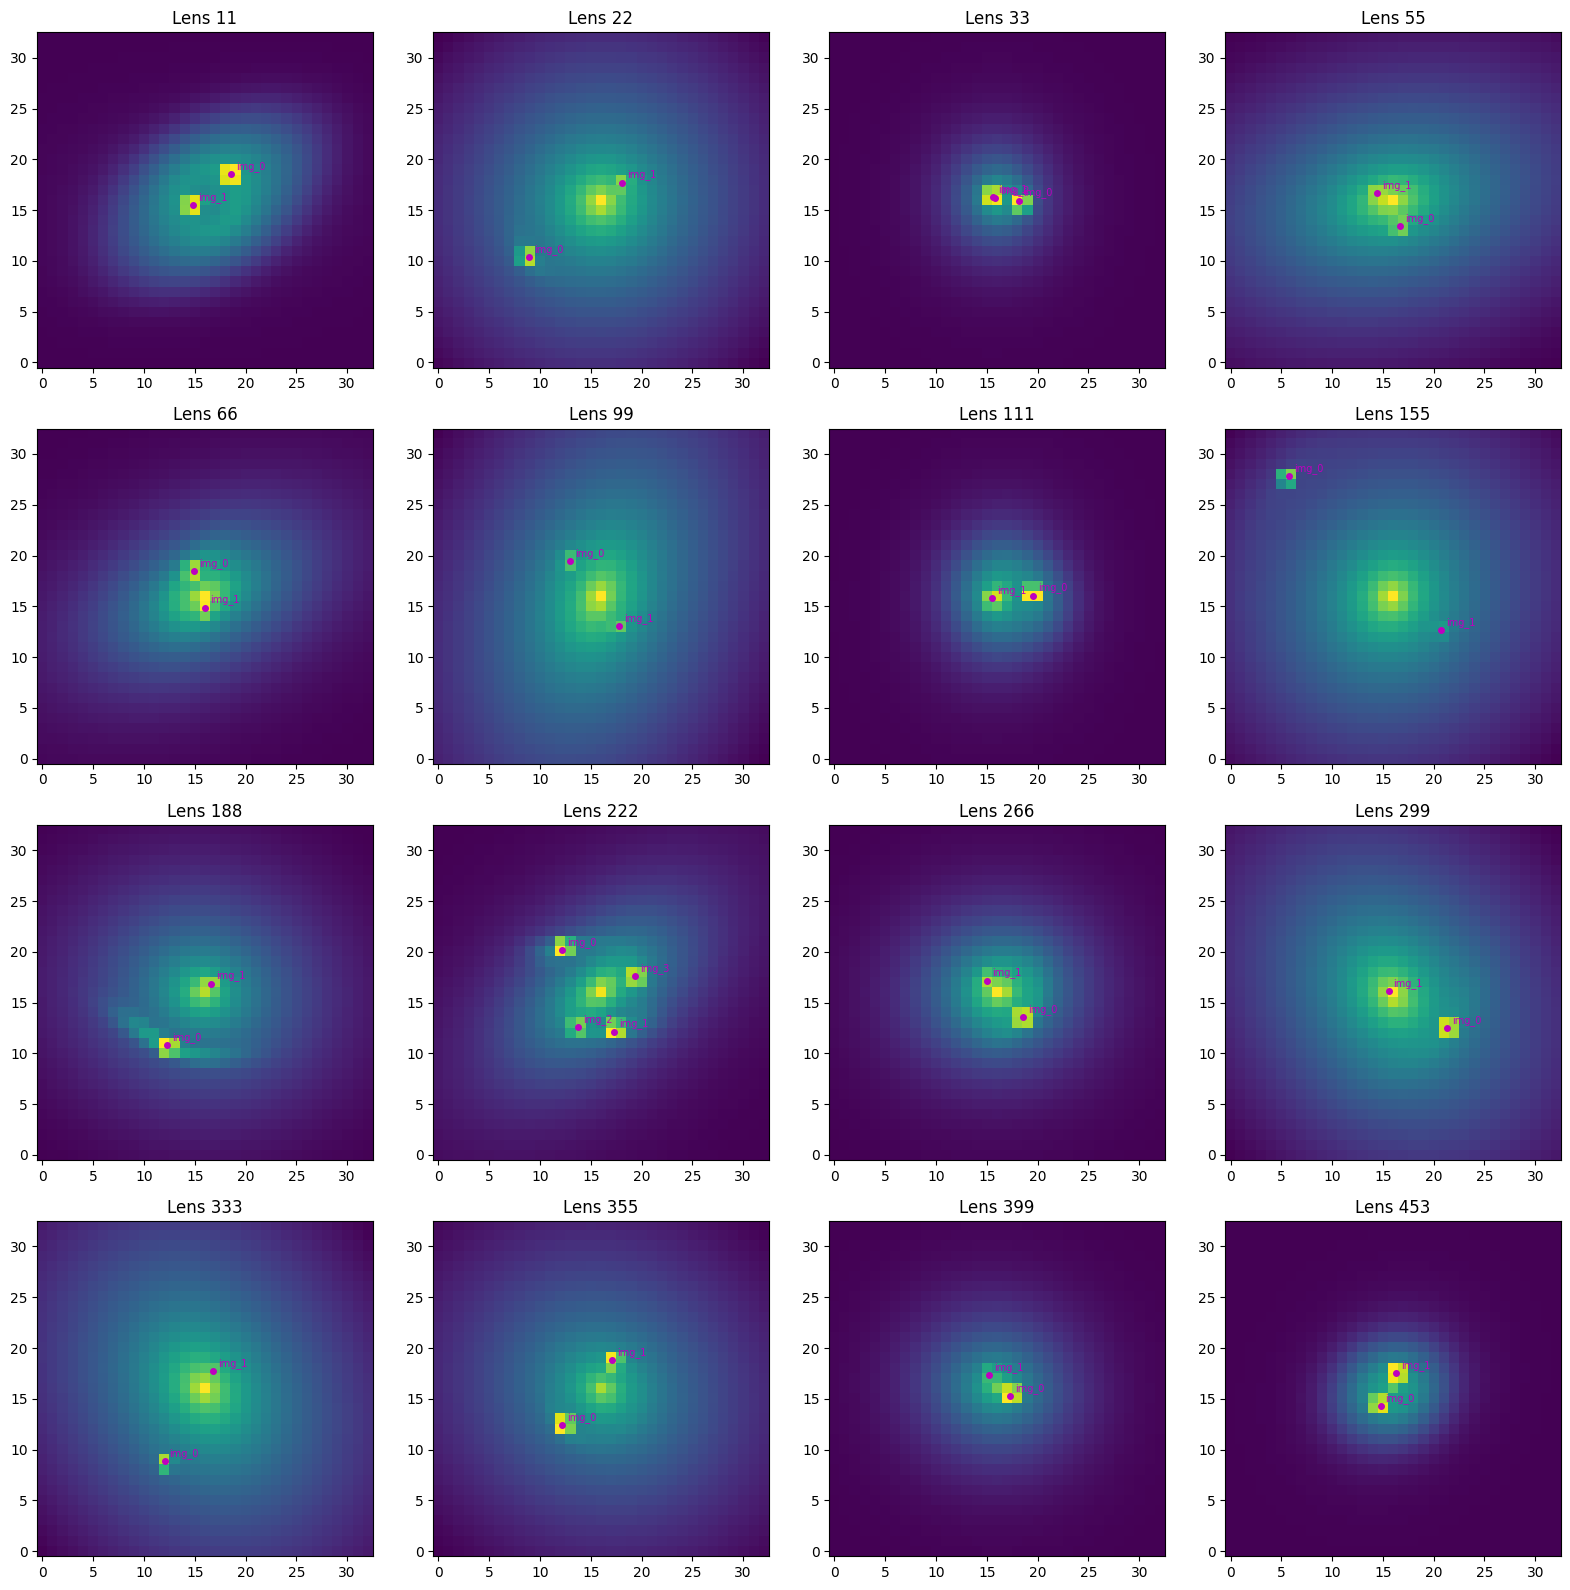

In [115]:
# Plot a grid of systems
fig, axs = plt.subplots(4, 4, figsize=(16, 16))
axs = axs.flatten()

for i, ind in enumerate(check_indices):
    arr = hf[f'lsst_lens_{ind}']['postage_stamps']['i']['all_observations'][0]
    axs[i].imshow(np.arcsinh(arr), origin="lower")
    xs, ys = get_point_xy(ind, 'i')
    _plot_points(axs[i], xs, ys)
    axs[i].set_title(f"Lens {ind}")

plt.tight_layout()

## Close file

In [116]:
hf.close()